# EE451 Parallel Prefix Scan (Colab Workflow)

Run top-to-bottom on Colab to:
1. Clone the `debug` branch.
2. Generate synthetic inputs.
3. Run sequential references.
4. Run the benchmark sweep.
5. Generate benchmark plots.
6. Run the full Nsight profiling sweep.
7. Analyze and validate profiling outputs.

Policy A:
- `D = {1, 16, 64, 256, 512}`
- `L = {1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072}`


In [ ]:
%cd /content
!rm -rf EE451_ParallelPrefixScanProject
!git clone https://github.com/pwang1092/EE451_ParallelPrefixScanProject
%cd EE451_ParallelPrefixScanProject
!git checkout debug
!git pull


/content
Cloning into 'EE451_ParallelPrefixScanProject'...
remote: Enumerating objects: 1047, done.
remote: Counting objects: 100% (826/826), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 1047 (delta 644), reused 760 (delta 588), pack-reused 221 (from 1)
Receiving objects: 100% (1047/1047), 9.43 MiB | 33.41 MiB/s, done.
Resolving deltas: 100% (763/763), done.
/content/EE451_ParallelPrefixScanProject
Branch 'debug' set up to track remote branch 'debug' from 'origin'.
Switched to a new branch 'debug'
Already up to date.


In [ ]:
!git -C /content/EE451_ParallelPrefixScanProject log -1 --pretty=format:'%h %s'

8e17b86 more bug fix

In [ ]:
%%bash
set -euo pipefail
nvidia-smi
which ncu
ncu --version
ncu --list-chips || true
if ncu --query-metrics --chips ga100 --csv >/tmp/ncu_metrics.csv 2>/dev/null; then
  head -n 5 /tmp/ncu_metrics.csv
elif ncu --query-metrics --chip sm_80 --csv >/tmp/ncu_metrics.csv 2>/dev/null; then
  head -n 5 /tmp/ncu_metrics.csv
else
  ncu --query-metrics --csv >/tmp/ncu_metrics.csv
  head -n 5 /tmp/ncu_metrics.csv
fi


Tue Apr 28 22:34:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             42W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!g++ -O2 -std=c++17 -o generate_inputs SyntheticData/generate_inputs.cpp
!./generate_inputs SyntheticData/inputs

!g++ -O2 -std=c++17 -o run_reference SequentialBaseline/run_reference.cpp
!./run_reference SyntheticData/inputs SequentialBaseline/SequentialData


wrote SyntheticData/inputs/input_B1_L1024_D1.bin  (0 MB)
wrote SyntheticData/inputs/input_B1_L1024_D16.bin  (0 MB)
wrote SyntheticData/inputs/input_B1_L1024_D64.bin  (0 MB)
wrote SyntheticData/inputs/input_B1_L1024_D256.bin  (2 MB)
wrote SyntheticData/inputs/input_B1_L1024_D512.bin  (4 MB)
wrote SyntheticData/inputs/input_B1_L2048_D1.bin  (0 MB)
wrote SyntheticData/inputs/input_B1_L2048_D16.bin  (0 MB)
wrote SyntheticData/inputs/input_B1_L2048_D64.bin  (1 MB)
wrote SyntheticData/inputs/input_B1_L2048_D256.bin  (4 MB)
wrote SyntheticData/inputs/input_B1_L2048_D512.bin  (8 MB)
wrote SyntheticData/inputs/input_B1_L4096_D1.bin  (0 MB)
wrote SyntheticData/inputs/input_B1_L4096_D16.bin  (0 MB)
wrote SyntheticData/inputs/input_B1_L4096_D64.bin  (2 MB)
wrote SyntheticData/inputs/input_B1_L4096_D256.bin  (8 MB)
wrote SyntheticData/inputs/input_B1_L4096_D512.bin  (16 MB)
wrote SyntheticData/inputs/input_B1_L8192_D1.bin  (0 MB)
wrote SyntheticData/inputs/input_B1_L8192_D16.bin  (1 MB)
wrote Synth

In [ ]:
!mkdir -p Results
!nvcc -O3 -std=c++17 -arch=sm_80 -o benchmark Kernels/benchmark.cu
!./benchmark SyntheticData/inputs SequentialBaseline/SequentialData Results


Kernels/benchmark.cu(181): warning #177-D: variable "num_chunks" was declared but never referenced
      const int num_chunks = (L + 1024 - 1) / 1024;
                ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

SSM Prefix Scan Benchmark  CHUNK_SIZE=1024
Dims: 1 16 64 256 512 
Lens: 1024 2048 4096 8192 16384 32768 65536 131072 

=== D = 1 ===
  warp_shuffle     D=1     L=1024        0.014 ms      0.86 GB/s  PASS
  blelloch         D=1     L=1024        0.018 ms      0.67 GB/s  PASS
  hillis_steele    D=1     L=1024        0.015 ms      0.80 GB/s  PASS
  warp_shuffle     D=1     L=2048        0.015 ms      1.60 GB/s  PASS
  blelloch         D=1     L=2048        0.019 ms      1.26 GB/s  PASS
  hillis_steele    D=1     L=2048        0.016 ms      1.50 GB/s  PASS
  warp_shuffle     D=1     L=4096        0.015 ms      3.20 GB/s  PASS
  blelloch         D=1     L=4096        0.020 ms      2.40 GB/s  PASS
  hillis_steele    D=1     L=4096        0.017 ms 

In [ ]:
import pandas as pd

df = pd.read_csv('Results/benchmark.csv')
print(df.head(12).to_string(index=False))
print('\nrows:', len(df))
print('D values:', sorted(df.D.unique()))
print('L values:', sorted(df.L.unique()))


       kernel  D    L  time_ms  correct  throughput_GB_s
 warp_shuffle  1 1024   0.0143        1            0.857
     blelloch  1 1024   0.0184        1            0.667
hillis_steele  1 1024   0.0154        1            0.800
 warp_shuffle  1 2048   0.0154        1            1.600
     blelloch  1 2048   0.0195        1            1.263
hillis_steele  1 2048   0.0164        1            1.500
 warp_shuffle  1 4096   0.0154        1            3.200
     blelloch  1 4096   0.0205        1            2.400
hillis_steele  1 4096   0.0174        1            2.824
 warp_shuffle  1 8192   0.0154        1            6.400
     blelloch  1 8192   0.0205        1            4.800
hillis_steele  1 8192   0.0174        1            5.647

rows: 120
D values: [np.int64(1), np.int64(16), np.int64(64), np.int64(256), np.int64(512)]
L values: [np.int64(1024), np.int64(2048), np.int64(4096), np.int64(8192), np.int64(16384), np.int64(32768), np.int64(65536), np.int64(131072)]


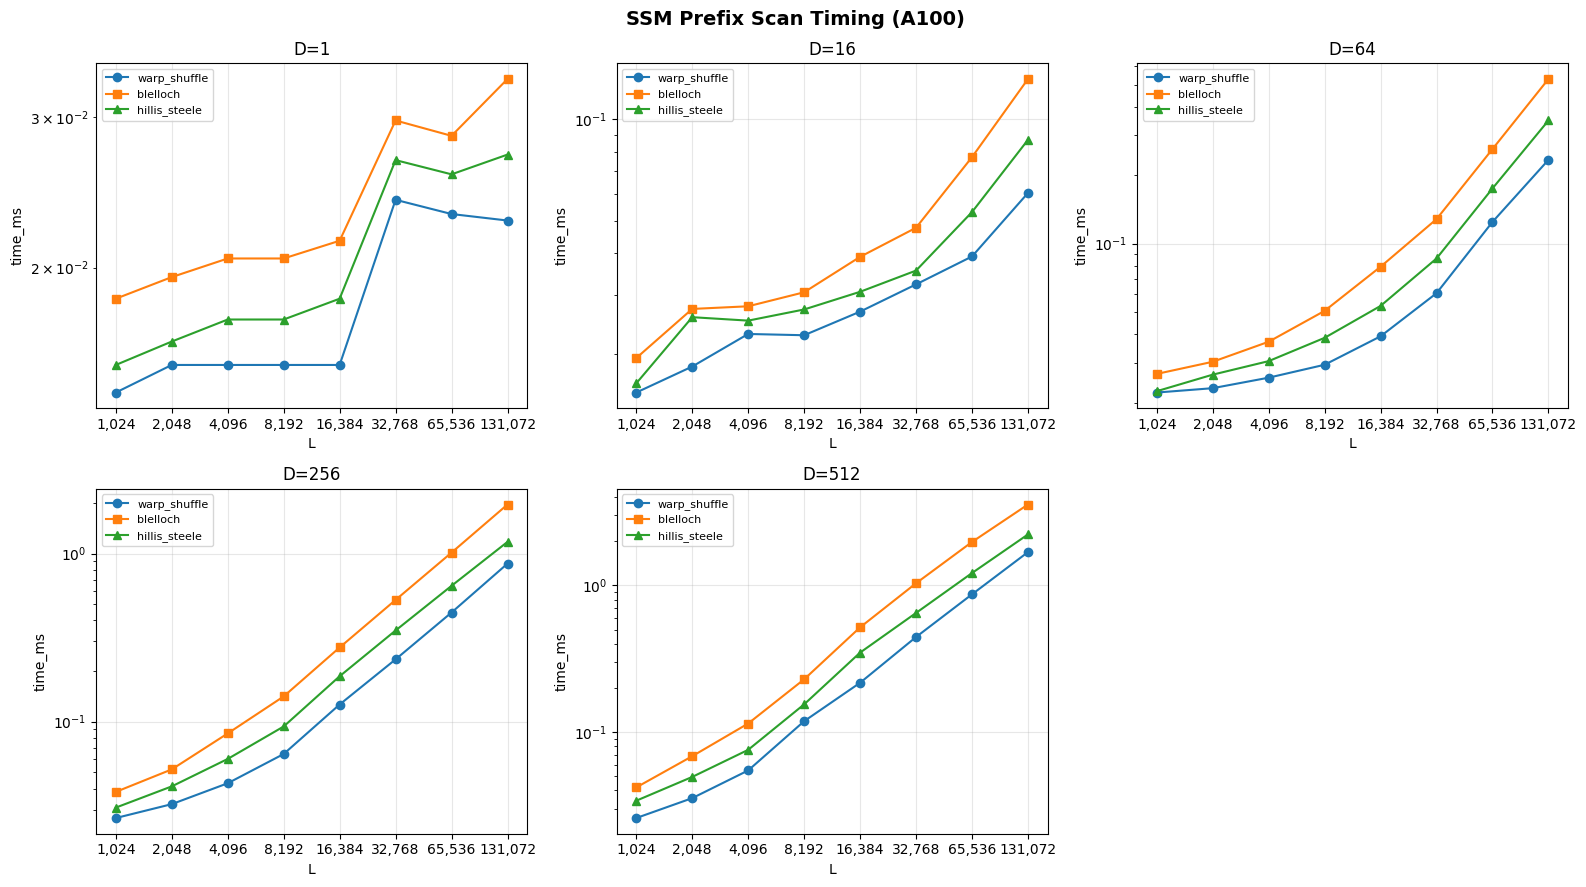

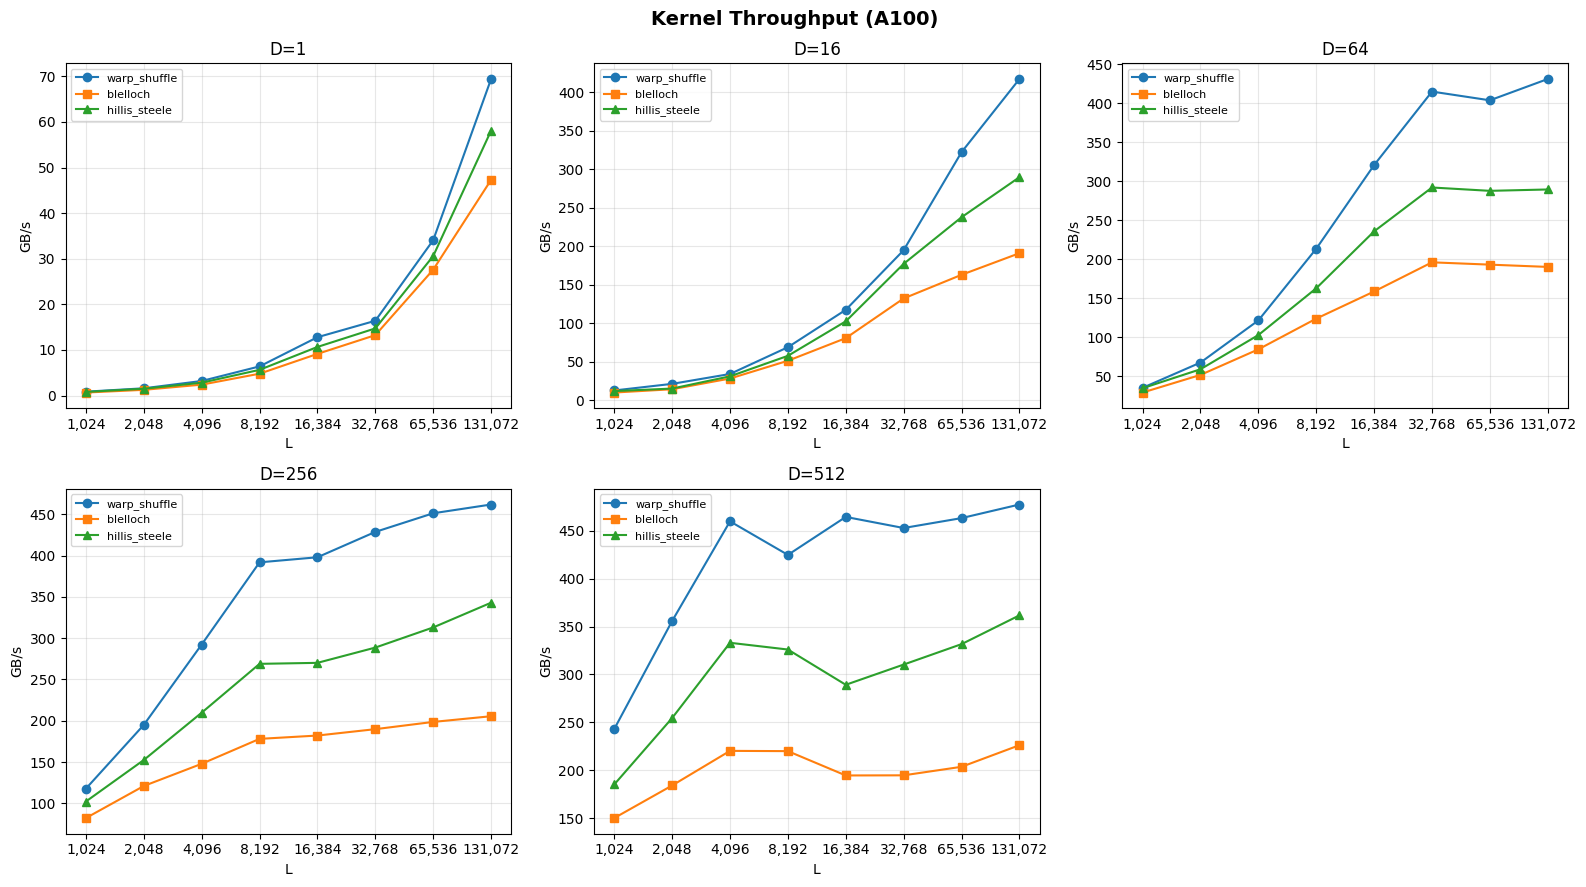

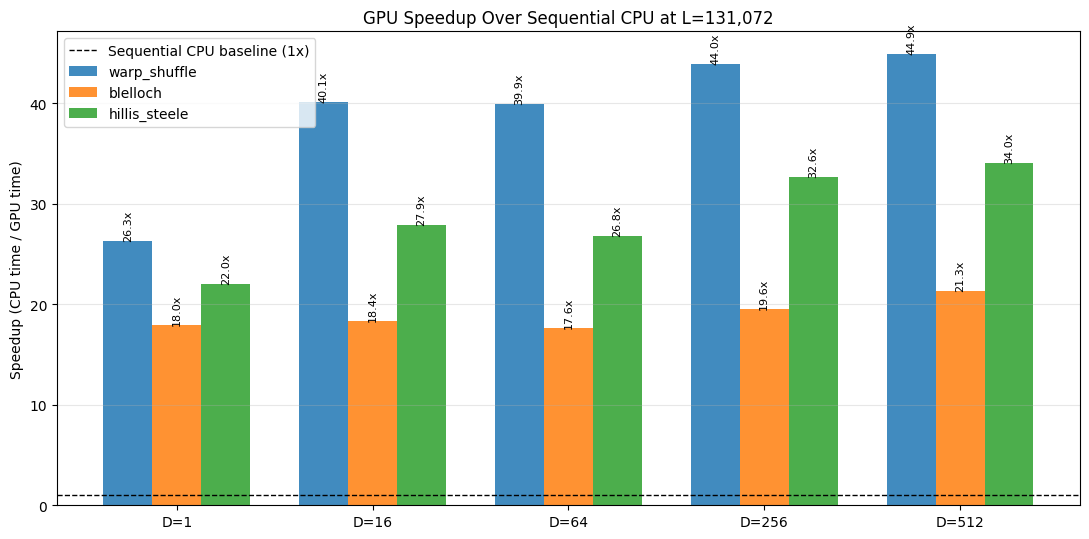

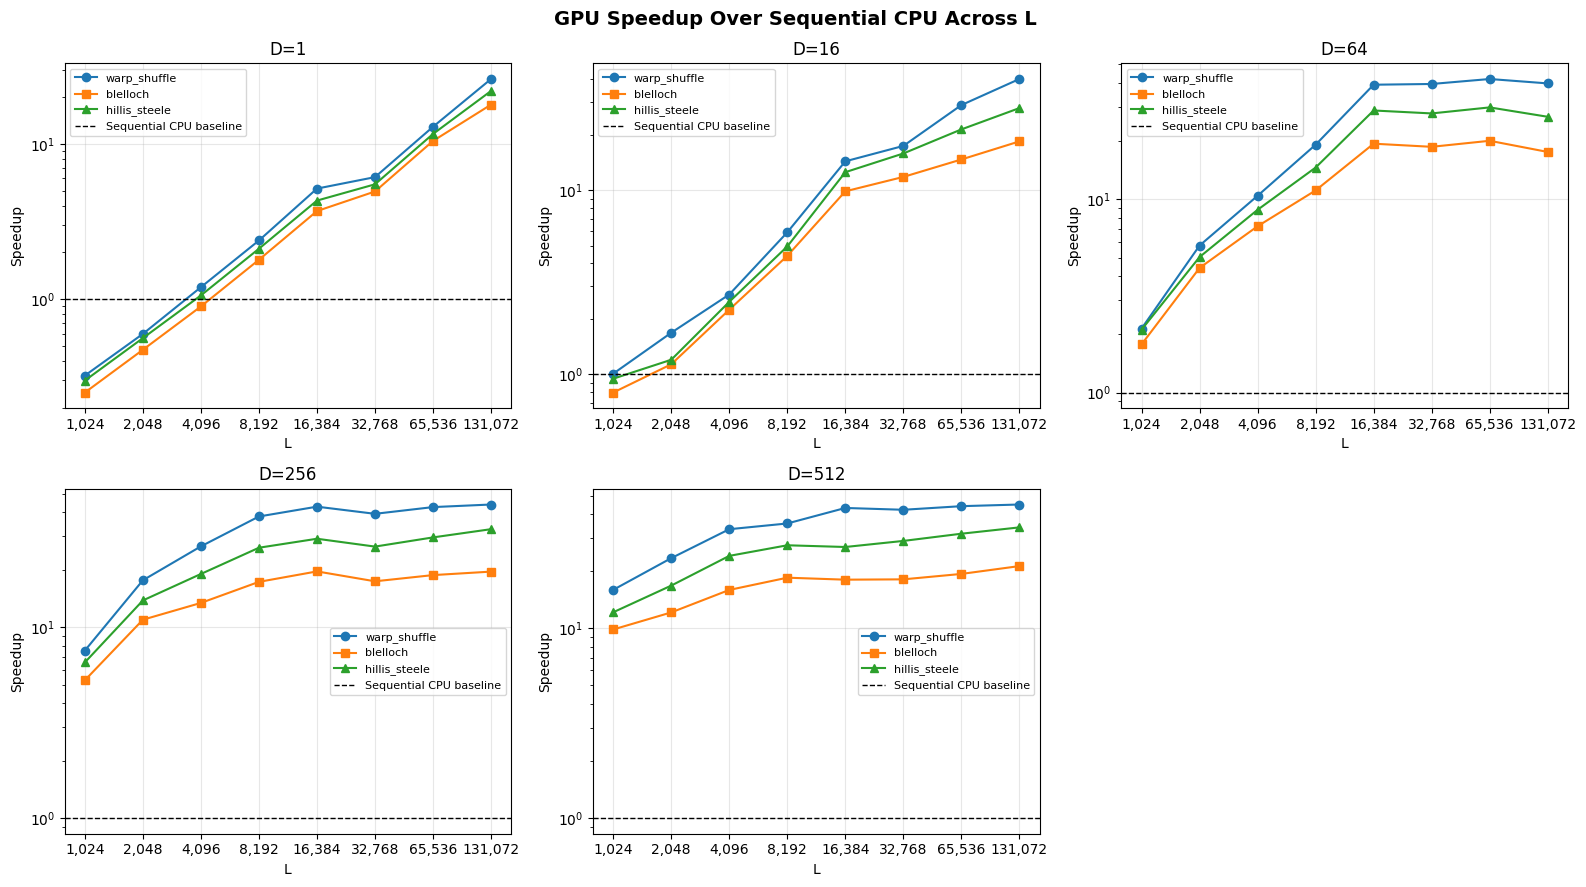

Saved:
 - Results/timing_plots.png
 - Results/fig_throughput_GBs.png
 - Results/fig_speedup_bars.png
 - Results/fig_speedup_vs_L.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

os.makedirs('Results', exist_ok=True)
gpu = pd.read_csv('Results/benchmark.csv')
seq = pd.read_csv('Results/sequential_baseline.csv')

D_VALUES = [1, 16, 64, 256, 512]
KERNELS = ['warp_shuffle', 'blelloch', 'hillis_steele']
COLORS = {'warp_shuffle':'#1f77b4','blelloch':'#ff7f0e','hillis_steele':'#2ca02c'}
MARKERS = {'warp_shuffle':'o','blelloch':'s','hillis_steele':'^'}

def fmt_L(x, _):
    return f"{int(x):,}"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, D in enumerate(D_VALUES):
    ax = axes[i]
    sub = gpu[gpu.D == D]
    for k in KERNELS:
        kdf = sub[sub.kernel == k].sort_values('L')
        ax.plot(kdf.L, kdf.time_ms, marker=MARKERS[k], color=COLORS[k], label=k)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_title(f'D={D}')
    ax.set_xlabel('L')
    ax.set_ylabel('time_ms')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_L))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('SSM Prefix Scan Timing (A100)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Results/timing_plots.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, D in enumerate(D_VALUES):
    ax = axes[i]
    sub = gpu[gpu.D == D]
    for k in KERNELS:
        kdf = sub[sub.kernel == k].sort_values('L')
        ax.plot(kdf.L, kdf.throughput_GB_s, marker=MARKERS[k], color=COLORS[k], label=k)
    ax.set_xscale('log', base=2)
    ax.set_title(f'D={D}')
    ax.set_xlabel('L')
    ax.set_ylabel('GB/s')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_L))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('Kernel Throughput (A100)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Results/fig_throughput_GBs.png', dpi=150, bbox_inches='tight')
plt.show()

L_TARGET = int(gpu.L.max())
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(D_VALUES))
w = 0.25
baseline = ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Sequential CPU baseline (1x)')
for j, k in enumerate(KERNELS):
    vals = []
    for D in D_VALUES:
        g = gpu[(gpu.kernel == k) & (gpu.D == D) & (gpu.L == L_TARGET)].time_ms.iloc[0]
        c = seq[(seq.D == D) & (seq.L == L_TARGET)].time_ms.iloc[0]
        vals.append(c / g)
    bars = ax.bar(x + (j - 1) * w, vals, width=w, label=k, color=COLORS[k], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val, f'{val:.1f}x', ha='center', va='bottom', fontsize=8, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels([f'D={d}' for d in D_VALUES])
ax.set_ylabel('Speedup (CPU time / GPU time)')
ax.set_title(f'GPU Speedup Over Sequential CPU at L={L_TARGET:,}')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('Results/fig_speedup_bars.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, D in enumerate(D_VALUES):
    ax = axes[i]
    cpu = seq[seq.D == D].sort_values('L')[['L', 'time_ms']].rename(columns={'time_ms': 'cpu_time_ms'})
    for k in KERNELS:
        kdf = gpu[(gpu.D == D) & (gpu.kernel == k)].sort_values('L')[['L', 'time_ms']]
        merged_speedup = kdf.merge(cpu, on='L', how='inner')
        speedup = merged_speedup['cpu_time_ms'] / merged_speedup['time_ms']
        ax.plot(merged_speedup['L'], speedup, marker=MARKERS[k], color=COLORS[k], label=k)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Sequential CPU baseline')
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_title(f'D={D}')
    ax.set_xlabel('L')
    ax.set_ylabel('Speedup')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_L))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('GPU Speedup Over Sequential CPU Across L', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Results/fig_speedup_vs_L.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved:')
print(' - Results/timing_plots.png')
print(' - Results/fig_throughput_GBs.png')
print(' - Results/fig_speedup_bars.png')
print(' - Results/fig_speedup_vs_L.png')


In [ ]:
# Full profiling runs by default so the notebook produces timing, plots,
# Nsight raw exports, and analysis outputs in one pass.
# Set this to False only if you want to skip the long profiling sweep.
%env RUN_FULL_PROFILING=True


env: RUN_FULL_PROFILING=True


In [ ]:
%%bash
if [ "${RUN_FULL_PROFILING:-False}" != "True" ]; then
  echo "RUN_FULL_PROFILING is False. Set it to True in previous cell and rerun this cell."
  exit 0
fi

set -euo pipefail
cd /content/EE451_ParallelPrefixScanProject
bash Kernels/profile_all_metrics.sh


Node:  d201b9701e0d
GPU:   NVIDIA A100-SXM4-40GB
Start: Tue Apr 28 11:34:34 PM UTC 2026
OUT:   /content/EE451_ParallelPrefixScanProject/Results/profile_run_colab_20260428_233434
Peak BW (GB/s): 2039
Peak FP32 (GFLOP/s): 19500

[Stage 1/3] Generate synthetic inputs
wrote /content/EE451_ParallelPrefixScanProject/SyntheticData/inputs/input_B1_L1024_D1.bin  (0 MB)
wrote /content/EE451_ParallelPrefixScanProject/SyntheticData/inputs/input_B1_L1024_D16.bin  (0 MB)
wrote /content/EE451_ParallelPrefixScanProject/SyntheticData/inputs/input_B1_L1024_D64.bin  (0 MB)
wrote /content/EE451_ParallelPrefixScanProject/SyntheticData/inputs/input_B1_L1024_D256.bin  (2 MB)
wrote /content/EE451_ParallelPrefixScanProject/SyntheticData/inputs/input_B1_L1024_D512.bin  (4 MB)
wrote /content/EE451_ParallelPrefixScanProject/SyntheticData/inputs/input_B1_L2048_D1.bin  (0 MB)
wrote /content/EE451_ParallelPrefixScanProject/SyntheticData/inputs/input_B1_L2048_D16.bin  (0 MB)
wrote /content/EE451_ParallelPrefixScanPro

In [ ]:
import glob
import os
import pandas as pd

runs = sorted(glob.glob('Results/profile_run_*'), key=os.path.getmtime)
if not runs:
    raise RuntimeError('No profiling run directory found under Results/.')

latest = runs[-1]
print('Latest profile run:', latest)

required = [
    'timing.csv',
    'merged_metrics.csv',
    'kernel_launch_metrics.csv',
    'phase_breakdown.csv',
    'occupancy_summary.csv',
    'analysis_report.txt',
]
for name in required:
    path = os.path.join(latest, name)
    print(f'{name}:', 'OK' if os.path.exists(path) else 'MISSING')

merged = pd.read_csv(os.path.join(latest, 'merged_metrics.csv'))
launches = pd.read_csv(os.path.join(latest, 'kernel_launch_metrics.csv'))
phases = pd.read_csv(os.path.join(latest, 'phase_breakdown.csv'))

print('\nmerged rows:', len(merged))
print('launch rows:', len(launches))
print('phase rows:', len(phases))

critical_cols = [
    'time_ms', 'correct', 'throughput_GB_s_timing',
    'sm_util_pct', 'achieved_occupancy_pct',
    'dram_bytes', 'flops', 'ai_flop_per_byte', 'gflops',
    'dram_bw_gb_s', 'bandwidth_util_pct', 'roofline_bound'
]
for col in critical_cols:
    print(f'NA {col}:', int(merged[col].isna().sum()))

print('NCU dram_bytes rows:', int((merged['dram_bytes_source'] == 'ncu').sum()), '/', len(merged))
print('NCU flops rows:', int((merged['flops_source'] == 'ncu').sum()), '/', len(merged))

if merged['dram_bytes'].isna().any() or merged['flops'].isna().any():
    raise RuntimeError('Roofline-critical columns still contain NA values.')

if (merged['dram_bytes_source'] != 'ncu').any() or (merged['flops_source'] != 'ncu').any():
    raise RuntimeError('Roofline metrics were not sourced from Nsight Compute for every run.')

print('\nSample merged rows:')
print(merged.head(6).to_string(index=False))


Latest profile run: Results/profile_run_colab_20260428_233434
timing.csv: OK
merged_metrics.csv: OK
kernel_launch_metrics.csv: OK
phase_breakdown.csv: OK
occupancy_summary.csv: OK
analysis_report.txt: OK

merged rows: 120
launch rows: 360
phase rows: 120
NA time_ms: 0
NA correct: 0
NA throughput_GB_s_timing: 0
NA sm_util_pct: 0
NA achieved_occupancy_pct: 0
NA dram_bytes: 0
NA flops: 0
NA ai_flop_per_byte: 0
NA gflops: 0
NA dram_bw_gb_s: 0
NA bandwidth_util_pct: 0
NA roofline_bound: 0
NCU dram_bytes rows: 120 / 120
NCU flops rows: 120 / 120

Sample merged rows:
       kernel  D    L  chunk_size  time_ms  correct  throughput_GB_s_timing  sm_util_pct  dram_util_pct  achieved_occupancy_pct  resident_warps_est  warp_efficiency_pct  registers_per_thread_peak  shared_mem_per_block_peak_bytes  block_size_peak  dram_bytes dram_bytes_source   flops flops_source  ai_flop_per_byte   gflops  dram_bw_gb_s  bandwidth_util_pct  l1_hit_rate_pct  l2_hit_rate_pct roofline_bound  roofline_limit_gflops  ro

### Get Figures (Roofline, utilization etc)

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as ticker, os

PROFILE_DIR = sorted(glob.glob('Results/profile_run_*'), key=os.path.getmtime)[-1]
merged = pd.read_csv(f'{PROFILE_DIR}/merged_metrics.csv')
phases = pd.read_csv(f'{PROFILE_DIR}/phase_breakdown.csv')

KERNELS = ['warp_shuffle', 'blelloch', 'hillis_steele']
COLORS  = {'warp_shuffle':'#1f77b4', 'blelloch':'#ff7f0e', 'hillis_steele':'#2ca02c'}
MARKERS = {'warp_shuffle':'o', 'blelloch':'s', 'hillis_steele':'^'}
D_VALUES = sorted(merged['D'].unique())
PEAK_BW_GBS   = 2039.0
PEAK_FP32_GFLOPS = 19500.0

In [ ]:
# ── Figure: Roofline (most important — directly answers memory vs compute bound) ──
# One subplot per D; each point is one (kernel, L) run.
# Ridge line = min(peak_BW * AI, peak_FLOPS).
# Points below the ridge = memory-bound. Points near the ridge = roofline-limited.

n = len(D_VALUES)
ncols = 2
nrows = (n + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 5*nrows))
axes = axes.flatten()

ai_roof = np.logspace(-2, 4, 500)
flops_roof = np.minimum(PEAK_BW_GBS * ai_roof, PEAK_FP32_GFLOPS)

for i, D in enumerate(D_VALUES):
    ax = axes[i]
    sub = merged[merged['D'] == D]
    ax.plot(ai_roof, flops_roof, 'k-', linewidth=2, label='Roofline', zorder=5)
    ax.axvline(PEAK_FP32_GFLOPS / PEAK_BW_GBS, color='gray', linestyle=':', alpha=0.6,
               label=f'Ridge ({PEAK_FP32_GFLOPS/PEAK_BW_GBS:.1f} FLOP/B)')
    for k in KERNELS:
        kdf = sub[sub['kernel'] == k].sort_values('L')
        ax.scatter(kdf['ai_flop_per_byte'], kdf['gflops'],
                   color=COLORS[k], marker=MARKERS[k], label=k, s=40, zorder=6)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Arithmetic Intensity (FLOP/byte)')
    ax.set_ylabel('Achieved GFLOPS')
    ax.set_title(f'D={D}')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Roofline Model — A100 SXM4\n(points left of ridge = memory-bound)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Results/fig_roofline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fig_roofline.png")

In [ ]:
# ── Figure: Achieved Occupancy vs L (one subplot per D) ──
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 5*nrows))
axes = axes.flatten()
for i, D in enumerate(D_VALUES):
    ax = axes[i]
    sub = merged[merged['D'] == D]
    for k in KERNELS:
        kdf = sub[sub['kernel'] == k].sort_values('L')
        ax.plot(kdf['L'], kdf['achieved_occupancy_pct'],
                marker=MARKERS[k], color=COLORS[k], label=k, linewidth=2)
    ax.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Max (100%)')
    ax.set_xscale('log', base=2)
    ax.set_ylim(0, 110)
    ax.set_xlabel('L'); ax.set_ylabel('Achieved Occupancy (%)')
    ax.set_title(f'D={D}')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Achieved Warp Occupancy vs Sequence Length\nA100 SXM4',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Results/fig_occupancy.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Figure: SM & Bandwidth Utilization vs D at L=131072 ──
# Shows the D-parallelism payoff directly — utilization should grow with D.
L_TARGET = merged['L'].max()
sub = merged[merged['L'] == L_TARGET]

x = np.arange(len(D_VALUES))
w = 0.25
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for j, k in enumerate(KERNELS):
    sm_vals  = [sub[(sub['kernel']==k) & (sub['D']==D)]['sm_util_pct'].values[0]        for D in D_VALUES]
    bw_vals  = [sub[(sub['kernel']==k) & (sub['D']==D)]['bandwidth_util_pct'].values[0] for D in D_VALUES]
    ax1.bar(x + (j-1)*w, sm_vals, w, label=k, color=COLORS[k], alpha=0.85)
    ax2.bar(x + (j-1)*w, bw_vals, w, label=k, color=COLORS[k], alpha=0.85)

for ax, title, ylabel in [
    (ax1, 'SM Utilization at L=131072', 'SM Util (%)'),
    (ax2, 'HBM Bandwidth Utilization at L=131072', 'BW Util (% of 2039 GB/s)')]:
    ax.set_xticks(x); ax.set_xticklabels([f'D={D}' for D in D_VALUES])
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('GPU Utilization vs Hidden Dimension D — A100 SXM4',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Results/fig_utilization.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Figure: Phase Breakdown (where does time actually go?) ──
if 'phase' in phases.columns and 'time_ms' in phases.columns:
    L_TARGET = phases['L'].max()
    sub = phases[phases['L'] == L_TARGET]
    phase_names = sorted(sub['phase'].unique())
    x = np.arange(len(D_VALUES))
    w = 0.25

    fig, axes = plt.subplots(1, len(KERNELS), figsize=(15, 5), sharey=True)
    phase_colors = {'phase1':'#1f77b4', 'phase2':'#ff7f0e', 'phase3':'#2ca02c'}

    for j, k in enumerate(KERNELS):
        ax = axes[j]
        bottom = np.zeros(len(D_VALUES))
        for ph in phase_names:
            vals = [sub[(sub['kernel']==k) & (sub['D']==D) & (sub['phase']==ph)]['time_ms'].values[0]
                    if len(sub[(sub['kernel']==k) & (sub['D']==D) & (sub['phase']==ph)]) > 0
                    else 0.0
                    for D in D_VALUES]
            ax.bar(x, vals, w*2, bottom=bottom, label=ph,
                   color=phase_colors.get(ph, 'gray'), alpha=0.85)
            bottom += np.array(vals)
        ax.set_xticks(x); ax.set_xticklabels([f'D={D}' for D in D_VALUES])
        ax.set_title(k); ax.set_xlabel('D')
        if j == 0: ax.set_ylabel('Time (ms)')
        ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

    plt.suptitle(f'Phase Time Breakdown at L={L_TARGET:,} — A100 SXM4',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('Results/fig_phase_breakdown.png', dpi=150, bbox_inches='tight')
    plt.show()

### Push stuff to github

In [ ]:
import os
from google.colab import userdata

# Retrieve your PAT from Colab secrets
# (Ensure you created a secret named 'GITHUB_TOKEN' in the left panel 🔑)
GITHUB_PAT = userdata.get('GITHUB_TOKEN')

# Set up the repo URL with the token for authentication
repo_url = f"https://{GITHUB_PAT}@github.com/pwang1092/EE451_ParallelPrefixScanProject.git"

# Change to the project directory and run the git commands
%cd /content/EE451_ParallelPrefixScanProject

!git checkout debug
!git status -sb
!git config --global user.email "aryanmisra0704@gmail.com"
!git config --global user.name "Miserabl"

# Stage only the full submission run directory
RUN_DIR = "Results/profile_run_colab_20260428_223528"
!git add {RUN_DIR}
!git commit -m "Add full A100 Colab profiling run for submission" || true

# Push using the authenticated URL explicitly
!git push {repo_url} debug

TimeoutException: Requesting secret GITHUB_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
!git push {repo_url} debug

Everything up-to-date


In [ ]:
!git push

On branch debug
Your branch is ahead of 'origin/debug' by 1 commit.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Results/benchmark.csv
	modified:   Results/fig_speedup_bars.png
	modified:   Results/fig_throughput_GBs.png
	modified:   Results/sequential_baseline.csv
	modified:   Results/timing_plots.png
	modified:   benchmark

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Results/fig_speedup_vs_L.png

no changes added to commit (use "git add" and/or "git commit -a")
